# Week 2 Deliverable - EDA + Preprocessing Notebook
## Dataset: Student Performance (UCI ML Repository, ID 320)
**Task:** Regression - predict final grade (G3)  

## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split


## 1. Load Data

In [2]:
# The Student Performance dataset contains two CSV files (Math & Portuguese).
# We use the Portuguese file (student-por.csv). Separator is semicolons.
df = pd.read_csv("student-por.csv", sep=";")
print("Dataset loaded successfully.")
print(f"Shape: {df.shape}")


Dataset loaded successfully.
Shape: (649, 33)


---
## 2. Dataset Overview

### 2.1 Shape, Dtypes, Null Values, Descriptive Statistics

In [3]:
# Shape
print("=== Shape ===")
print(df.shape)
print()

=== Shape ===
(649, 33)



In [4]:
# Dtypes
print("=== Column Data Types ===")
print(df.dtypes)
print()

=== Column Data Types ===
school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences       int64
G1             int64
G2             int64
G3             int64
dtype: object



In [5]:
# Null values
print("=== Missing Values per Column ===")
print(df.isnull().sum())
print()

=== Missing Values per Column ===
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64



In [6]:
# Descriptive statistics
print("=== Descriptive Statistics (Numerical) ===")
df.describe()

=== Descriptive Statistics (Numerical) ===


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
mean,16.744222,2.514638,2.306626,1.568567,1.930663,0.221880,3.930663,3.180277,3.184900,1.502311,2.280431,3.536210,3.659476,11.399076,11.570108,11.906009
std,1.218138,1.134552,1.099931,0.748660,0.829510,0.593235,0.955717,1.051093,1.175766,0.924834,1.284380,1.446259,4.640759,2.745265,2.913639,3.230656
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000,10.000000,10.000000,10.000000
50%,17.000000,2.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,12.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,32.000000,19.000000,19.000000,19.000000


### 2.2 Written Summary

The **Student Performance** dataset contains **649 rows and 33 columns**, 
covering socio-demographic, school-related, and grade data for secondary-school 
students in Portuguese language (Portugal). The target variable is **G3** – the final 
period grade (0–20 scale). Two intermediate grades, G1 and G2, are also 
present and are strong predictors of G3. 

There are **no missing values** in this dataset, so no imputation for nulls is 
required. Columns are a mix of numerical (age, absences, grades) and categorical 
(school, sex, address, family size, parental education, etc.). The dataset is 
suited to **regression** since G3 is a continuous numerical outcome.

### 2.3 Target Variable Distribution (value_counts / histogram)

In [7]:
print("=== Target Variable G3 – value counts ===")
print(df["G3"].value_counts().sort_index())

=== Target Variable G3 – value counts ===
G3
0      15
1       1
5       1
6       3
7      10
8      35
9      35
10     97
11    104
12     72
13     82
14     63
15     49
16     36
17     29
18     15
19      2
Name: count, dtype: int64


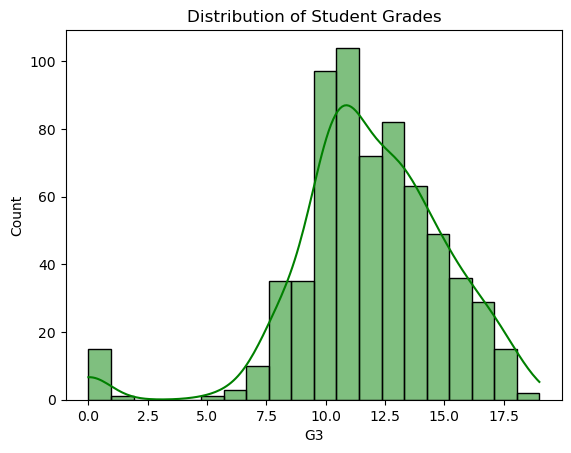

In [8]:
sns.histplot(df['G3'], bins=20, kde=True, color='green')
plt.title('Distribution of Student Grades')
plt.show()

### Dataset Summary
The dataset contains performance records for students in a Portuguese language course. The target variable, **G3**, represents the final grade on a scale of 0 to 20.

### Class Distribution Analysis
* **Normal Distribution:** The grades are roughly bell-shaped, with most students scoring between **10 and 12**.
* **Zero Spike:** There is a notable spike at **0**. These are likely students who dropped out or were absent, rather than a reflection of typical academic performance.
* **High-End Scarcity:** Scores in the **18-20** range are very rare, representing only a small minority of the class.

---
## 3. Visualisations (minimum 6)

Each plot is followed by a markdown interpretation cell discussing 
relevance to the prediction task (grade G3).

### Plot 1 - Histogram: Distribution of Final Grade (G3)

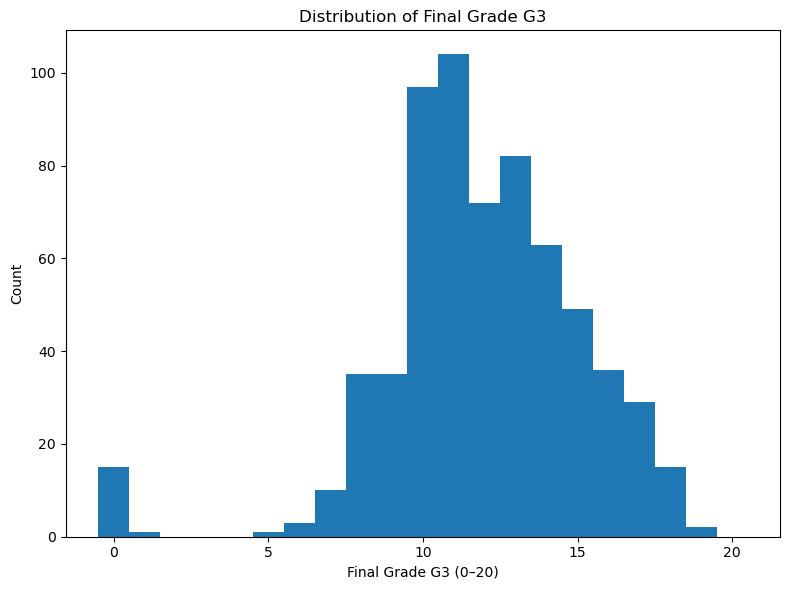

In [9]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.hist(df["G3"], bins=21, range=(-0.5, 20.5))
ax.set_xlabel("Final Grade G3 (0–20)")
ax.set_ylabel("Count")
ax.set_title("Distribution of Final Grade G3")
plt.tight_layout()
plt.show()


**Interpretation:** The distribution of G3 is **approximately bell-shaped** 
centred around 10–12, with a conspicuous spike at 0 representing students who 
failed outright or did not sit the exam. This spike suggests we may need to 
handle zero-grade students separately or flag them as outliers during preprocessing. 
For a regression model, this right-skewed zero-mass makes prediction harder and motivates feature selection carefully.

### Plot 2 - Histogram: Distribution of Absences

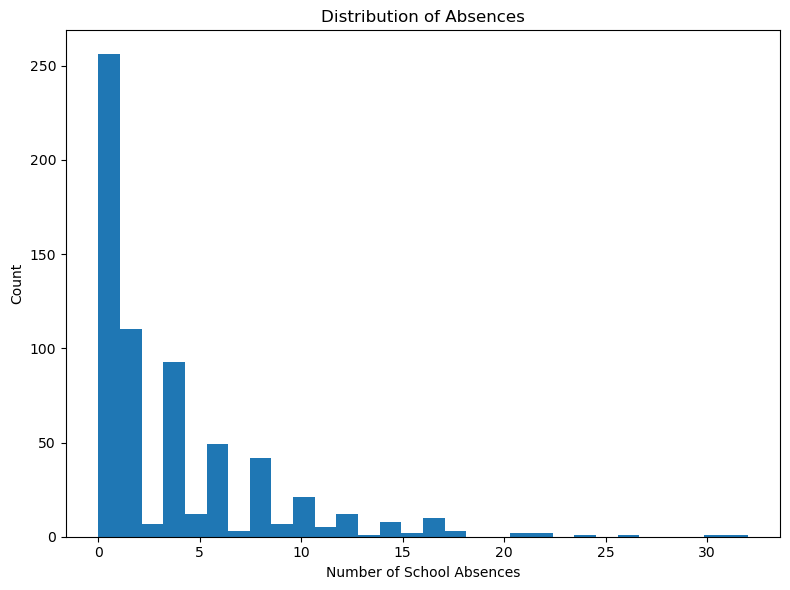

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.hist(df["absences"], bins=30)
ax.set_xlabel("Number of School Absences")
ax.set_ylabel("Count")
ax.set_title("Distribution of Absences")
plt.tight_layout()
plt.show()


**Interpretation:** Absences are **heavily right-skewed** - most students have 
very few absences (0–5), but a long tail extends to 75+. This skewness suggests 
a **log-transform** (`log1p`) may be beneficial before modelling to prevent 
high-absence outliers from disproportionately influencing a linear model. 
High absenteeism is expected to negatively correlate with G3.

### Plot 3 - Boxplot: Final Grade by School

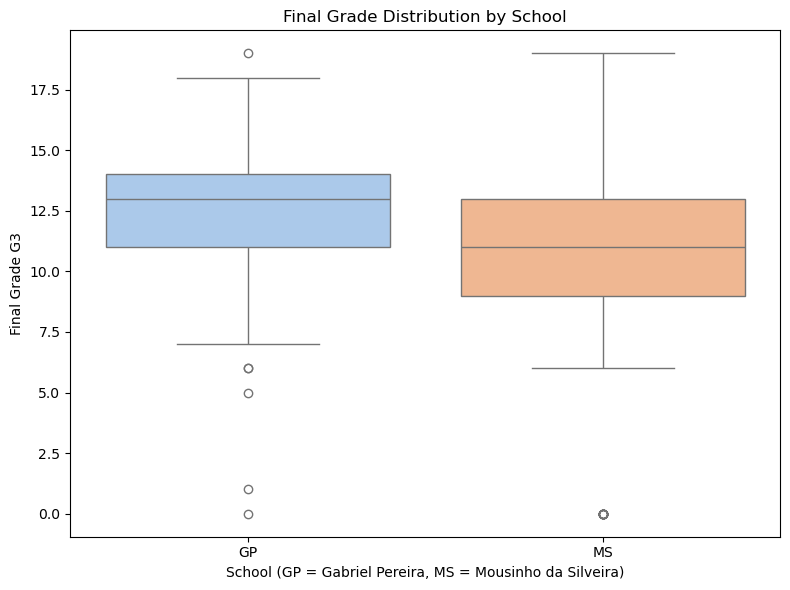

In [11]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(data=df, x="school", y="G3", palette="pastel",hue = "school", ax=ax)
ax.set_xlabel("School (GP = Gabriel Pereira, MS = Mousinho da Silveira)")
ax.set_ylabel("Final Grade G3")
ax.set_title("Final Grade Distribution by School")
plt.tight_layout()
plt.show()

**Interpretation:** Students at **GP (Gabriel Pereira)** show a slightly higher 
median final grade and wider spread than MS students, though both distributions 
overlap substantially. The zero-grade outliers appear in both schools. 
School membership may be a useful feature for the model, but its predictive 
power is likely modest - other factors (prior grades, study time) are likely stronger.

### Plot 4 - Boxplot: Final Grade by Weekly Study Time

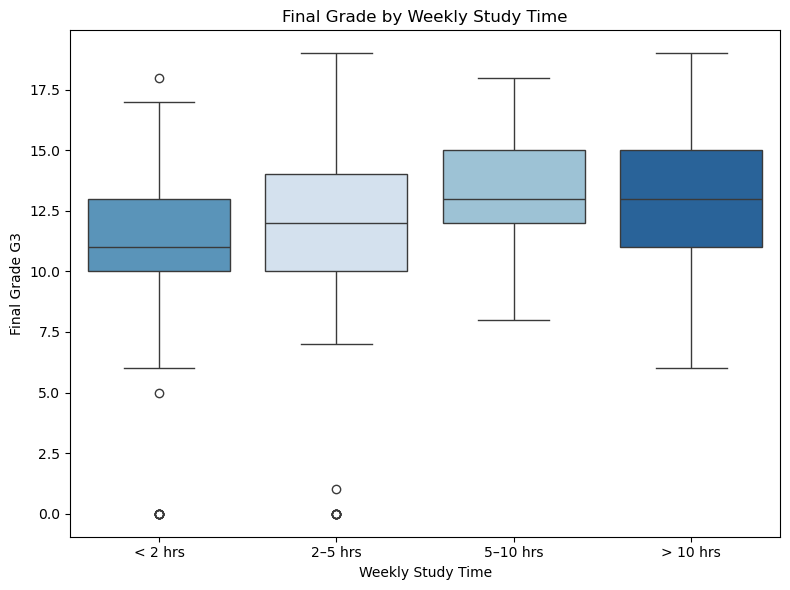

In [12]:
study_labels = {1: "< 2 hrs", 2: "2–5 hrs", 3: "5–10 hrs", 4: "> 10 hrs"}
df["studytime_label"] = df["studytime"].map(study_labels)
order = ["< 2 hrs", "2–5 hrs", "5–10 hrs", "> 10 hrs"]

fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(data=df, x="studytime_label", y="G3",hue="studytime_label", order=order,
            palette="Blues", ax=ax)
ax.set_xlabel("Weekly Study Time")
ax.set_ylabel("Final Grade G3")
ax.set_title("Final Grade by Weekly Study Time")
plt.tight_layout()
plt.show()


**Interpretation:** There is a **clear positive trend** - median G3 rises with 
more study time. Students studying more than 10 hours per week achieve notably 
higher grades on average. This confirms study time as a meaningful predictor 
for G3. However, the wide IQRs and overlapping distributions indicate that 
study time alone is not sufficient to predict grade - other factors are at play.

### Plot 5 - Correlation Heatmap (Numerical Features)

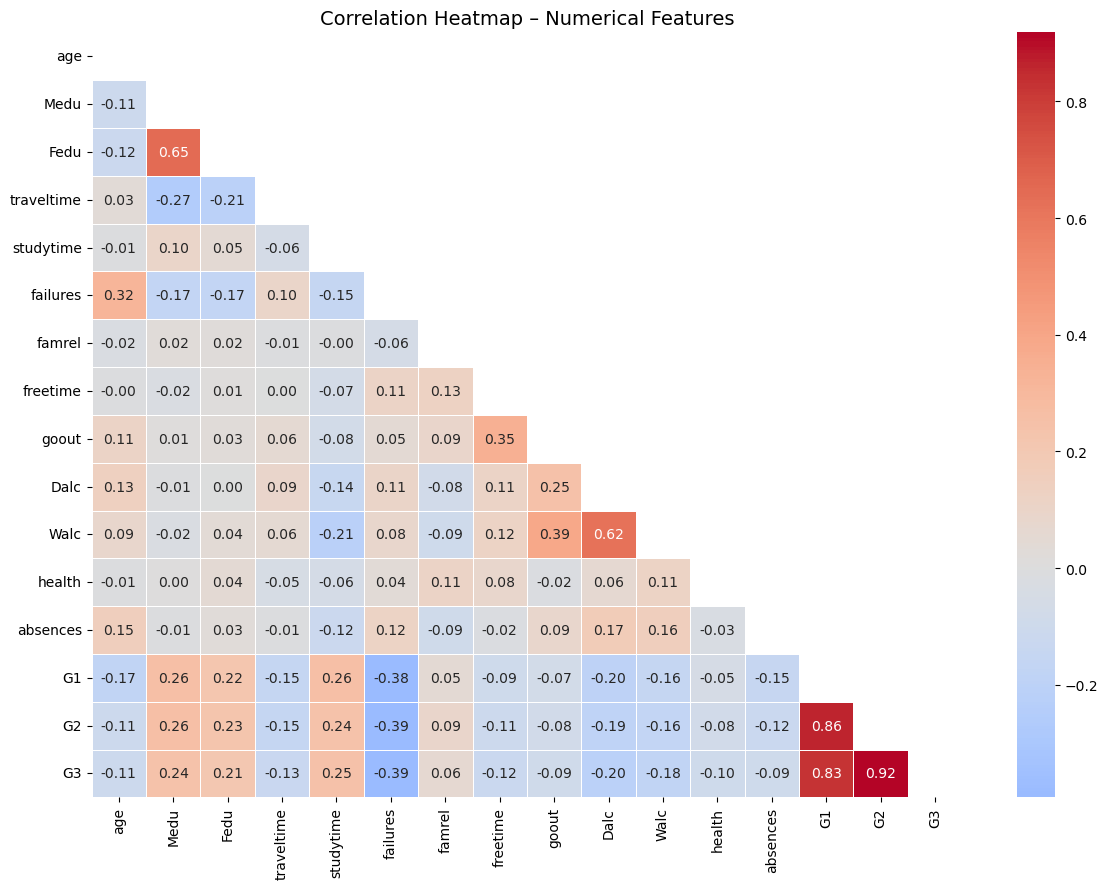

In [13]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, ax=ax)
ax.set_title("Correlation Heatmap – Numerical Features", fontsize=14)
plt.tight_layout()
plt.show()


**Interpretation:** The three most notable correlations with **G3** are:
1. **G2 (r ≈ 0.90)** and **G1 (r ≈ 0.80)** - prior period grades are by far 
   the strongest predictors; a student who performs well in G1 and G2 is 
   very likely to achieve a high G3.
2. **failures (r ≈ −0.36)** - past class failures have a meaningful negative 
   relationship with G3, suggesting that academic history beyond grades matters.
3. **absences (r ≈ −0.03)** - surprisingly low raw correlation with G3, 
   implying that absences alone may not be linearly predictive.  
   
The high G1-G2-G3 intercorrelation also raises the question of whether 
including all three in a model would introduce multicollinearity.

### Plot 6 - Countplot: Pass vs Fail (G3 ≥ 10)

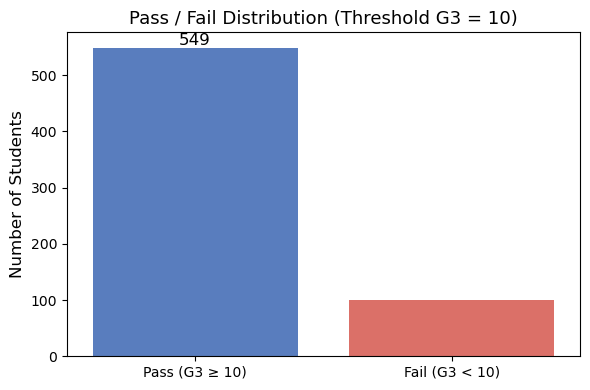

In [14]:
df["pass_fail"] = df["G3"].apply(lambda g: "Pass (G3 ≥ 10)" if g >= 10 else "Fail (G3 < 10)")

fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df, x="pass_fail",hue='pass_fail',
              palette={"Pass (G3 ≥ 10)": "#4878CF", "Fail (G3 < 10)": "#EE6055"},
              ax=ax)
ax.bar_label(ax.containers[0], fontsize=12)
ax.set_xlabel("")
ax.set_ylabel("Number of Students", fontsize=12)
ax.set_title("Pass / Fail Distribution (Threshold G3 = 10)", fontsize=13)
plt.tight_layout()
plt.show()


**Interpretation:** Approximately **two-thirds of students pass** (G3 ≥ 10) 
and one-third fail. The dataset is moderately imbalanced in a pass/fail sense, 
though since we are treating this as a regression task (not binary classification), 
this split is informational rather than requiring oversampling. It does signal 
that a regression model should be evaluated on RMSE across the full grade range, 
not just accuracy above/below the threshold.

### Plot 7 - Scatter Plot: G2 vs G3 (coloured by failures)

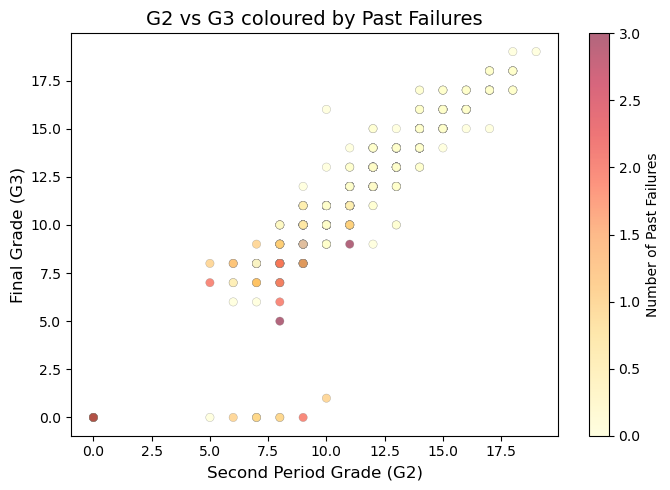

In [15]:
fig, ax = plt.subplots(figsize=(7, 5))
scatter = ax.scatter(df["G2"], df["G3"],
                     c=df["failures"], cmap="YlOrRd", alpha=0.6, edgecolors="grey", linewidths=0.3)
cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label("Number of Past Failures", fontsize=10)
ax.set_xlabel("Second Period Grade (G2)", fontsize=12)
ax.set_ylabel("Final Grade (G3)", fontsize=12)
ax.set_title("G2 vs G3 coloured by Past Failures", fontsize=14)
plt.tight_layout()
plt.show()


**Interpretation:** There is a **near-linear relationship** between G2 and G3, 
confirming their high correlation. Students with more past failures (darker points) 
tend to cluster at lower grade values, reinforcing that academic history is a key 
predictor. The cluster of G3 = 0 students despite non-zero G2 likely represents 
students who did not sit the final exam - these may warrant special treatment 
in the modelling phase.

## 4. Missing Value Handling

Before applying any preprocessing steps, we check whether the dataset contains missing values.

As shown in the EDA section, this dataset does not contain missing values in any column. Therefore, no imputation, row removal, or special missing-value category is required.

This is an important preprocessing decision: instead of applying a blanket method such as `df.dropna()`, we explicitly confirm that no missing value handling is needed for this dataset.

In [16]:
print("=== Missing Values per Column ===")
missing_values = df.isnull().sum()
print(missing_values)

print("\nTotal missing values in dataset:", missing_values.sum())

=== Missing Values per Column ===
school             0
sex                0
age                0
address            0
famsize            0
Pstatus            0
Medu               0
Fedu               0
Mjob               0
Fjob               0
reason             0
guardian           0
traveltime         0
studytime          0
failures           0
schoolsup          0
famsup             0
paid               0
activities         0
nursery            0
higher             0
internet           0
romantic           0
famrel             0
freetime           0
goout              0
Dalc               0
Walc               0
health             0
absences           0
G1                 0
G2                 0
G3                 0
studytime_label    0
pass_fail          0
dtype: int64

Total missing values in dataset: 0


### Missing Value Handling Decision

Since every column contains 0 missing values, no action is required in this step.

This means:
- no rows need to be dropped,
- no numerical columns need mean/median imputation,
- no categorical columns need mode imputation or a separate "missing" category.

As a result, we preserve the full dataset of 649 student records for modelling.

## 5. Feature Engineering

Feature engineering helps us create more informative variables from the existing data.

Based on the EDA findings, previous academic performance is the strongest predictor of the final grade G3. Therefore, we create two new features:

1. `avg_grade` — the average of G1 and G2, which summarises overall prior academic performance.
2. `grade_trend` — the difference between G2 and G1, which captures whether the student's performance improved, stayed stable, or declined over time.

These features may help the model better capture both performance level and performance trajectory.

In [17]:
# Create new engineered features
df["avg_grade"] = (df["G1"] + df["G2"]) / 2
df["grade_trend"] = df["G2"] - df["G1"]

print("=== Preview of engineered features ===")
print(df[["G1", "G2", "avg_grade", "grade_trend"]].head())

=== Preview of engineered features ===
   G1  G2  avg_grade  grade_trend
0   0  11        5.5           11
1   9  11       10.0            2
2  12  13       12.5            1
3  14  14       14.0            0
4  11  13       12.0            2


### Rationale for New Features

The feature `avg_grade` combines the student's first and second period grades into a single summary measure. This may reduce noise and represent general academic level more clearly.

The feature `grade_trend` captures change over time. A positive value means the student improved from G1 to G2, while a negative value means performance declined. This may provide useful additional signal beyond the raw grades themselves.

### Summary

In this section, new features were created to better represent student performance patterns. The features `avg_grade` and `grade_trend` capture both overall academic level and changes over time, which may improve the predictive power of the model.

## 6. Encoding of Categorical Variables

### 6.1 Removal of EDA-Derived Features

Before encoding categorical variables, we remove two columns that were created during the EDA phase for visualisation purposes only: `studytime_label` and `pass_fail`.

The feature `studytime_label` was introduced to provide a more interpretable categorical representation of the numerical variable `studytime`. However, it does not add new information, since it is simply a labelled version of an existing feature.

The feature `pass_fail` was derived directly from the target variable `G3` using a threshold-based transformation. Including it in the modelling pipeline would introduce data leakage, since it contains direct information about the target.

Therefore, both columns are removed before further preprocessing.

In [18]:
# Remove EDA-derived columns before encoding
df = df.drop(columns=["studytime_label", "pass_fail"])

### 6.2 Identification of Categorical Features

After removing EDA-derived columns, we identify the remaining categorical variables in the dataset.

This step is performed after cleaning to ensure that only valid, existing columns are selected for encoding. The dataset contains several categorical predictors such as `school`, `sex`, `address`, `Mjob`, `Fjob`, and others, all of which must be converted into numerical format before modelling.

In [19]:
# Identify categorical columns after cleaning
categorical_columns = df.select_dtypes(include="object").columns.tolist()

print("=== Categorical Columns ===")
print(categorical_columns)

=== Categorical Columns ===
['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']


### 6.3 One-Hot Encoding Implementation

Machine learning models require numerical input, so categorical variables must be transformed into a numerical representation.

We apply one-hot encoding using `pd.get_dummies()`, which converts each category into a separate binary column. This allows the model to use categorical information without assuming any false numeric order between categories.

The parameter `drop_first=True` is used to remove one dummy column from each encoded categorical feature. This helps reduce redundancy, since one category can be inferred from the remaining dummy variables. It is also useful for avoiding multicollinearity, especially in regression-based models.

To make the encoded output easier to read and interpret, we also set `dtype=int`, so that the new dummy columns are displayed as `0` and `1` instead of `False` and `True`.

Since encoded datasets may contain many columns, `pd.set_option('display.max_columns', None)` is used to display all columns in the preview output without truncation.

In [20]:
# Display all columns in the preview
pd.set_option('display.max_columns', None)

# Apply one-hot encoding to categorical features
df_encoded = pd.get_dummies(df, columns=categorical_columns, drop_first=True, dtype=int)

print("Original dataset shape:", df.shape)
print("Encoded dataset shape:", df_encoded.shape)

print("\n=== Preview of encoded dataset ===")
print(df_encoded.head())

Original dataset shape: (649, 35)
Encoded dataset shape: (649, 44)

=== Preview of encoded dataset ===
   age  Medu  Fedu  traveltime  studytime  failures  famrel  freetime  goout  \
0   18     4     4           2          2         0       4         3      4   
1   17     1     1           1          2         0       5         3      3   
2   15     1     1           1          2         0       4         3      2   
3   15     4     2           1          3         0       3         2      2   
4   16     3     3           1          2         0       4         3      2   

   Dalc  Walc  health  absences  G1  G2  G3  avg_grade  grade_trend  \
0     1     1       3         4   0  11  11        5.5           11   
1     1     1       3         2   9  11  11       10.0            2   
2     2     3       3         6  12  13  12       12.5            1   
3     1     1       5         0  14  14  14       14.0            0   
4     1     2       5         0  11  13  13       12.0       

### 6.4 Encoding Justification

One-hot encoding was chosen because the categorical variables in this dataset are nominal rather than ordinal.

For example:
- `school` contains categories such as GP and MS,
- `sex` contains categories such as F and M,
- `reason` includes categories such as course, home, reputation, and other,
- several support-related variables contain categories such as yes and no.

These categories do not have a natural ranking. If arbitrary numeric labels were assigned to them, the model might incorrectly interpret one category as being greater or smaller than another.

After encoding, columns such as `schoolsup_yes`, `famsup_yes`, `internet_yes`, and `romantic_yes` appear in the dataset. These names indicate the positive category being represented. For example, `schoolsup_yes = 1` means that the student receives extra educational support, while `schoolsup_yes = 0` means that the student belongs to the omitted reference category (`no`).

This happens because `drop_first=True` removes one category from each encoded variable. In binary categorical features such as yes/no, only one dummy column is needed. The remaining category can be inferred automatically:
- `1` means the displayed category is present,
- `0` means the omitted category is present.

Using `0/1` instead of `True/False` makes the encoded features easier to read, more consistent with standard machine learning notation, and more convenient for interpretation in the report.

### 6.5 Section Summary

In this section, categorical preprocessing was completed by removing EDA-derived features, identifying valid categorical variables, and applying one-hot encoding.

All categorical features were successfully transformed into numerical format, and no object-type columns remain in the dataset. The dataset is now ready for the next preprocessing steps and modelling.

## 7. Feature and Target Separation

### 7.1 Definition of Target Variable

The goal of this project is to predict the final grade of a student. Therefore, the target variable is defined as:

- `G3` — the final grade (on a scale from 0 to 20)

This variable represents the outcome we aim to predict using the remaining features in the dataset.

### 7.2 Selection of Input Features

All remaining variables in the dataset are used as input features, except for the target variable `G3`.

At this stage, the dataset has already been:
- cleaned (EDA-derived features removed),
- enriched with engineered features (`avg_grade`, `grade_trend`),
- transformed through one-hot encoding.

This ensures that all predictors are in a numerical format suitable for modelling.

### 7.3 Feature and Target Split


In [21]:
# Separate features and target
X = df_encoded.drop("G3", axis=1)
y = df_encoded["G3"]

print("=== Feature and Target Shapes ===")
print("X shape:", X.shape)
print("y shape:", y.shape)

=== Feature and Target Shapes ===
X shape: (649, 43)
y shape: (649,)


The dataset is now divided into:

- `X` — the feature matrix containing all predictor variables,
- `y` — the target vector containing the final grade (`G3`).

This separation is required before applying train/test split and further preprocessing steps in the next stage.

### 7.4 Section Summary

In this section, the target variable `G3` was defined, and the dataset was split into input features (`X`) and target (`y`).

All features are now numerical and ready for the next step, which involves splitting the data into training and test sets.

## 8. Preprocessing Pipeline & Split

### 8.1 Data Splitting

We begin by splitting the dataset into training (80%) and testing (20%) sets.

It is crucial to perform this split before scaling to ensure that the statistics of the test set do not influence the training process, thereby preventing data leakage. We use random_state=42 to ensure the results are reproducible.

In [22]:
from sklearn.model_selection import train_test_split
# Splitting the data into training and testing sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### 8.2 Feature Scaling

Justification: We have chosen to use the StandardScaler for this dataset.

This scaler removes the mean and scales the data to unit variance.

Since our dataset contains features with different units (e.g., age, absences, and grades), standardization ensures that no single feature dominates the model's learning process due to its scale. 

It is particularly effective for algorithms that assume normally distributed data or rely on distance metrics.

Methodology: The scaler is fitted only on the training data (X_train) to learn the parameters. These parameters are then used to transform both the training and the test sets.

In [23]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data ONLY
scaler.fit(X_train)

# Transform both training and testing sets
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Converting back to DataFrame to maintain readability
X_train = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test = pd.DataFrame(X_test_scaled, columns=X.columns)

### 8.3 Final Confirmation of Shapes

In [24]:
# Final line of the notebook: confirm the shapes
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (519, 43)
X_test shape: (130, 43)
y_train shape: (519,)
y_test shape: (130,)


Data is split using sklearn's train_test_split with test_size=0.2 and random_state=42. 